<a href="https://colab.research.google.com/github/DarioCorona/personal/blob/root/NB3_Sesion1_Tarea_Comparacion_Equipos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Módulo 4 · Estadística Aplicada y Confiabilidad de Activos
## Sesión 1 — Estadística descriptiva y distribución de fallas

Programa de Certificación en Ciencia de Datos aplicada al Mantenimiento Predictivo

### Notebook 3 · Tarea — Comparar distribuciones de falla entre equipos

**Nivel:** esta tarea va más allá de pedirle a un LLM el código: requiere que **tú** compares resultados entre varios equipos, tomes una decisión justificada y la comuniques por escrito. Un asistente de IA puede ayudarte a escribir una función o depurar un error, pero el análisis comparativo y la conclusión son tuyos.

**Entrega:** notebook ejecutado + una celda final de conclusiones (mínimo 150 palabras) con tu recomendación de mantenimiento para cada equipo.

## Contexto

El equipo de confiabilidad de la planta quiere saber, para **cada uno de los 5 equipos**, qué tipo de comportamiento de falla presentan (aleatorio, desgaste o mortalidad infantil) para decidir si conviene mantenimiento preventivo por tiempo fijo o mantenimiento basado en condición.

In [ ]:
import numpy as np
import pandas as pd

# Conjunto de activos de la planta metalúrgica (mismo caso usado desde el Módulo 2).
# Cada equipo tiene un comportamiento de falla distinto (parámetros de Weibull reales
# que iremos "descubriendo" con estadística a lo largo de la sesión).
EQUIPOS = {
    "Bomba Centrífuga":       {"beta": 2.8, "eta": 850,  "n_fallas": 60},
    "Motor Eléctrico":        {"beta": 1.0, "eta": 1200, "n_fallas": 55},
    "Compresor de Aire":      {"beta": 0.6, "eta": 400,  "n_fallas": 70},
    "Ventilador Industrial":  {"beta": 2.2, "eta": 1000, "n_fallas": 50},
    "Transportador de Banda": {"beta": 1.1, "eta": 900,  "n_fallas": 58},
}

def generar_tbf(equipo, params, seed):
    """Genera tiempos entre fallas (TBF, en horas) para un equipo usando una Weibull."""
    rng = np.random.default_rng(seed)
    tbf = rng.weibull(params["beta"], params["n_fallas"]) * params["eta"]
    return pd.DataFrame({"equipo": equipo, "tbf_horas": tbf})

fallas = pd.concat(
    [generar_tbf(eq, p, seed=i) for i, (eq, p) in enumerate(EQUIPOS.items())],
    ignore_index=True,
)
fallas.head()


,equipo,tbf_horas
0,Bomba Centrífuga,740.602455
1,Bomba Centrífuga,855.912043
2,Bomba Centrífuga,209.477435
3,Bomba Centrífuga,96.626541
4,Bomba Centrífuga,686.733096


## Parte 1 — Estadística descriptiva por equipo

Construye una tabla con media, mediana, desviación estándar, IQR, **asimetría** y **curtosis** del TBF **para cada uno de los 5 equipos** (pista: `fallas.groupby("equipo")["tbf_horas"].describe()` es un buen punto de partida, pero se te pide que agregues también el IQR, la asimetría y la curtosis, que `describe()` no incluye — usa `scipy.stats.skew` y `scipy.stats.kurtosis`, igual que en el Notebook 1).

In [ ]:
# Tu código: tabla de estadística descriptiva por equipo, incluyendo IQR, asimetría y curtosis


In [ ]:
from scipy.stats import skew, kurtosis

descriptive_stats = fallas.groupby('equipo')['tbf_horas'].agg([
    'mean',
    'median',
    'std',
    lambda x: x.quantile(0.75) - x.quantile(0.25), # IQR
    skew,
    kurtosis
]).rename(columns={'<lambda_0>': 'iqr', '<lambda_1>': 'skewness', '<lambda_2>': 'kurtosis'})

display(descriptive_stats)

,mean,median,std,iqr,skew,kurtosis
equipo,,,,,,
Bomba Centrífuga,771.499200,770.432034,312.910361,423.073331,0.064904,-0.015300
Compresor de Aire,460.081407,203.180165,649.834629,484.641027,2.336980,5.547915
Motor Eléctrico,1375.605349,943.506623,1700.755084,1297.207748,3.114114,11.988124
Transportador de Banda,1024.291293,691.802454,989.767234,897.462459,1.792317,3.483975
Ventilador Industrial,905.127638,886.093259,423.214779,588.679295,0.250390,-0.414840


## Parte 2 — Ajuste de distribuciones por equipo

Para cada equipo, ajusta Normal, Exponencial y Weibull, y determina cuál ajusta mejor según KS. Organiza el resultado en una sola tabla con columnas: `equipo`, `mejor_distribución`, `KS_stat`, `parámetro_forma_weibull` (si aplica).

Además, para **al menos un equipo** de tu elección, reproduce las dos visualizaciones que vimos en el Notebook 1: el histograma con las tres densidades superpuestas, y el gráfico Q-Q de la distribución ganadora (`stats.probplot`).

,equipo,mejor_distribución,KS_stat,parámetro_forma_weibull
0,Bomba Centrífuga,Normal,0.042078,3.298940
1,Compresor de Aire,Exponencial,0.182081,0.657880
2,Motor Eléctrico,Exponencial,0.079005,0.791832
3,Transportador de Banda,Exponencial,0.079396,0.704059
4,Ventilador Industrial,Normal,0.051973,2.551624


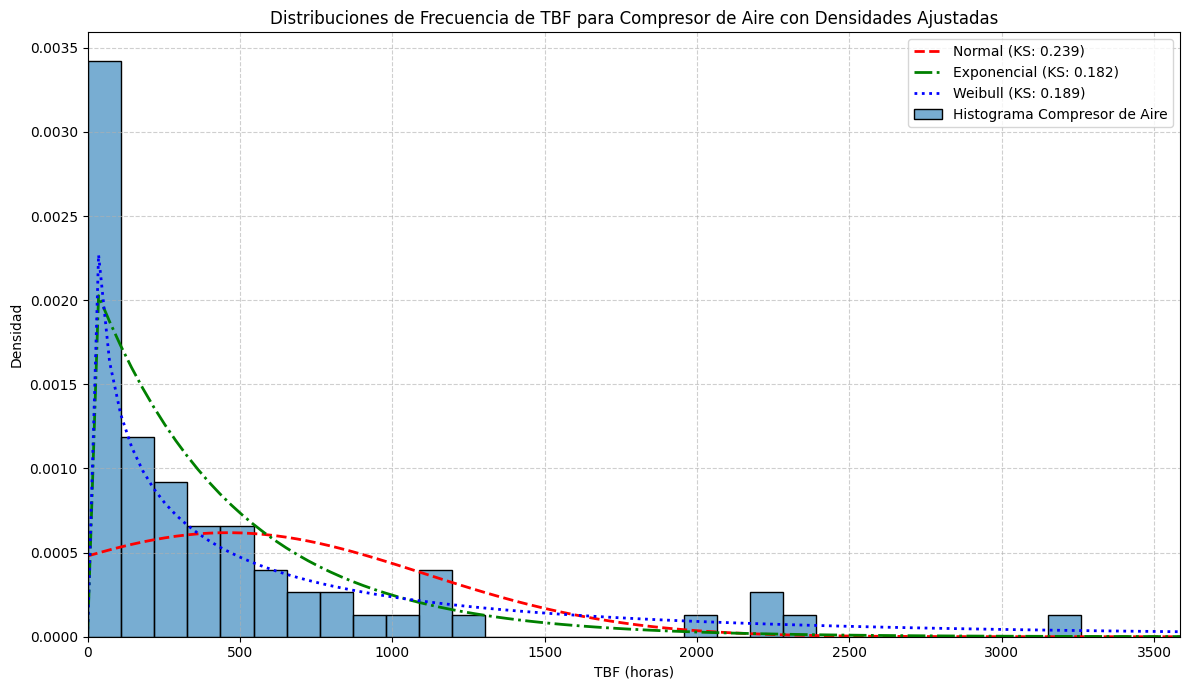

In [ ]:
from scipy.stats import norm, expon, weibull_min, kstest, probplot
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Código para el ajuste de distribuciones y tabla resumen ---

def fit_and_test_distributions(data):
    results = {}

    # Normal Distribution
    mu_norm, std_norm = norm.fit(data)
    ks_stat_norm, p_value_norm = kstest(data, 'norm', args=(mu_norm, std_norm))
    results['Normal'] = {'KS_stat': ks_stat_norm, 'params': (mu_norm, std_norm)}

    # Exponential Distribution
    loc_expon, scale_expon = expon.fit(data)
    ks_stat_expon, p_value_expon = kstest(data, 'expon', args=(loc_expon, scale_expon))
    results['Exponencial'] = {'KS_stat': ks_stat_expon, 'params': (loc_expon, scale_expon)}

    # Weibull Distribution
    c_weibull, loc_weibull, scale_weibull = weibull_min.fit(data)
    ks_stat_weibull, p_value_weibull = kstest(data, 'weibull_min', args=(c_weibull, loc_weibull, scale_weibull))
    results['Weibull'] = {'KS_stat': ks_stat_weibull, 'params': (c_weibull, loc_weibull, scale_weibull)}

    # Determine the best distribution based on the minimum KS statistic
    best_dist = min(results, key=lambda k: results[k]['KS_stat'])

    return best_dist, results


# Prepare to store the results for all equipment
all_equipment_dist_results = []

for equipo_name, group_data in fallas.groupby('equipo'):
    tbf_data = group_data['tbf_horas']
    best_dist_name, dist_results = fit_and_test_distributions(tbf_data)

    best_result = dist_results[best_dist_name]

    # Extract Weibull beta parameter if Weibull is the best fit, or if it was fitted anyway
    weibull_params = dist_results['Weibull']['params']
    param_forma_weibull = weibull_params[0] if 'Weibull' in dist_results else None

    all_equipment_dist_results.append({
        'equipo': equipo_name,
        'mejor_distribución': best_dist_name,
        'KS_stat': best_result['KS_stat'],
        'parámetro_forma_weibull': param_forma_weibull
    })

# Create a DataFrame from the results
distribution_summary_df = pd.DataFrame(all_equipment_dist_results)
display(distribution_summary_df)


# --- Código para visualizaciones del equipo seleccionado ---
chosen_equipment = 'Compresor de Aire'
chosen_data = fallas[fallas['equipo'] == chosen_equipment]['tbf_horas']

# Re-fit distributions for the chosen equipment to get parameters
_, chosen_dist_results = fit_and_test_distributions(chosen_data)

# Get parameters for plotting
mu_norm, std_norm = chosen_dist_results['Normal']['params']
loc_expon, scale_expon = chosen_dist_results['Exponencial']['params']
c_weibull, loc_weibull, scale_weibull = chosen_dist_results['Weibull']['params']

# Plotting the histogram with superimposed densities
plt.figure(figsize=(12, 7))
sns.histplot(chosen_data, kde=False, bins=30, stat='density', alpha=0.6, label=f'Histograma {chosen_equipment}')

# Ensure xmin starts from 0 as TBF cannot be negative
xmin_plot = 0
xmax_plot = chosen_data.max() * 1.1 # Extend slightly beyond max for better visualization
x = np.linspace(xmin_plot, xmax_plot, 100)

# Plot Normal PDF
p_norm = norm.pdf(x, mu_norm, std_norm)
plt.plot(x, p_norm, 'r--', linewidth=2, label=f'Normal (KS: {chosen_dist_results["Normal"]["KS_stat"]:.3f})')

# Plot Exponential PDF
p_expon = expon.pdf(x, loc_expon, scale_expon)
plt.plot(x, p_expon, 'g-.', linewidth=2, label=f'Exponencial (KS: {chosen_dist_results["Exponencial"]["KS_stat"]:.3f})')

# Plot Weibull PDF
p_weibull = weibull_min.pdf(x, c_weibull, loc_weibull, scale_weibull)
plt.plot(x, p_weibull, 'b:', linewidth=2, label=f'Weibull (KS: {chosen_dist_results["Weibull"]["KS_stat"]:.3f})')

plt.title(f'Distribuciones de Frecuencia de TBF para {chosen_equipment} con Densidades Ajustadas')
plt.xlabel('TBF (horas)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(xmin_plot, xmax_plot) # Set x-axis limits explicitly
plt.tight_layout()
plt.show()

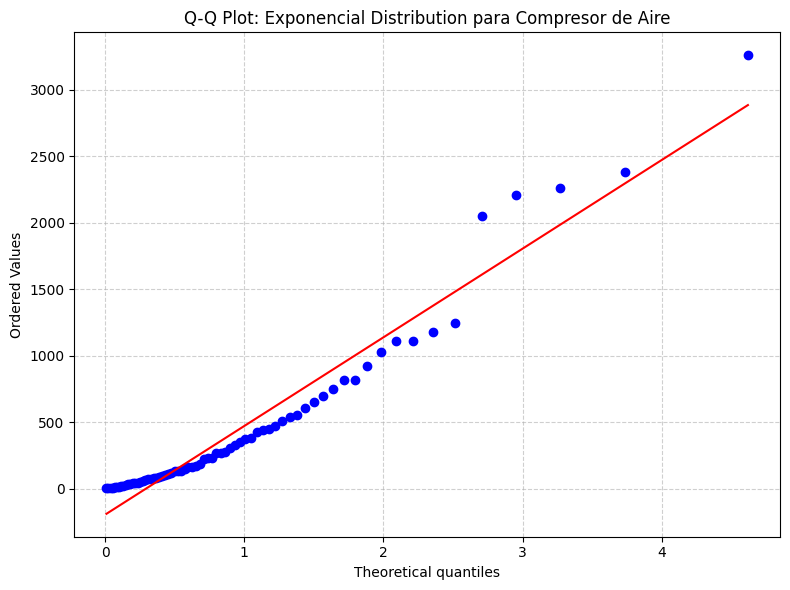

In [ ]:
# Q-Q plot para la distribución que mejor ajusta
best_dist_name_chosen, _ = fit_and_test_distributions(chosen_data)

plt.figure(figsize=(8, 6))
if best_dist_name_chosen == 'Normal':
    probplot(chosen_data, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot: Normal Distribution para {chosen_equipment}')
elif best_dist_name_chosen == 'Exponencial':
    probplot(chosen_data, dist="expon", plot=plt)
    plt.title(f'Q-Q Plot: Exponencial Distribution para {chosen_equipment}')
elif best_dist_name_chosen == 'Weibull':
    # Recuperar los parámetros de Weibull para el equipo elegido del 'chosen_dist_results'
    c_weibull_qq, loc_weibull_qq, scale_weibull_qq = chosen_dist_results['Weibull']['params']
    probplot(chosen_data, dist=weibull_min, sparams=(c_weibull_qq, loc_weibull_qq, scale_weibull_qq), plot=plt)
    plt.title(f'Q-Q Plot: Weibull Distribution para {chosen_equipment}')
else:
    print(f"No Q-Q plot disponible para {best_dist_name_chosen}")

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Ajuste de Distribuciones y Test de Kolmogorov-Smirnov (KS)

Vamos a ajustar las distribuciones Normal, Exponencial y Weibull a los datos de `tbf_horas` para cada equipo. Utilizaremos el test de Kolmogorov-Smirnov (KS) para determinar cuál es la mejor distribución.

In [ ]:
from scipy.stats import norm, expon, weibull_min, kstest, probplot
import matplotlib.pyplot as plt
import seaborn as sns

def fit_and_test_distributions(data):
    results = {}

    # Normal Distribution
    mu_norm, std_norm = norm.fit(data)
    ks_stat_norm, p_value_norm = kstest(data, 'norm', args=(mu_norm, std_norm))
    results['Normal'] = {'KS_stat': ks_stat_norm, 'params': (mu_norm, std_norm)}

    # Exponential Distribution
    loc_expon, scale_expon = expon.fit(data)
    ks_stat_expon, p_value_expon = kstest(data, 'expon', args=(loc_expon, scale_expon))
    results['Exponencial'] = {'KS_stat': ks_stat_expon, 'params': (loc_expon, scale_expon)}

    # Weibull Distribution
    c_weibull, loc_weibull, scale_weibull = weibull_min.fit(data)
    ks_stat_weibull, p_value_weibull = kstest(data, 'weibull_min', args=(c_weibull, loc_weibull, scale_weibull))
    results['Weibull'] = {'KS_stat': ks_stat_weibull, 'params': (c_weibull, loc_weibull, scale_weibull)}

    # Determine the best distribution based on the minimum KS statistic
    best_dist = min(results, key=lambda k: results[k]['KS_stat'])

    return best_dist, results


# Prepare to store the results for all equipment
all_equipment_dist_results = []

for equipo_name, group_data in fallas.groupby('equipo'):
    tbf_data = group_data['tbf_horas']
    best_dist_name, dist_results = fit_and_test_distributions(tbf_data)

    best_result = dist_results[best_dist_name]

    # Extract Weibull beta parameter if Weibull is the best fit, or if it was fitted anyway
    weibull_params = dist_results['Weibull']['params']
    param_forma_weibull = weibull_params[0] if 'Weibull' in dist_results else None

    all_equipment_dist_results.append({
        'equipo': equipo_name,
        'mejor_distribución': best_dist_name,
        'KS_stat': best_result['KS_stat'],
        'parámetro_forma_weibull': param_forma_weibull # Always include Weibull beta for later classification
    })

# Create a DataFrame from the results
distribution_summary_df = pd.DataFrame(all_equipment_dist_results)
display(distribution_summary_df)

,equipo,mejor_distribución,KS_stat,parámetro_forma_weibull
0,Bomba Centrífuga,Normal,0.042078,3.298940
1,Compresor de Aire,Exponencial,0.182081,0.657880
2,Motor Eléctrico,Exponencial,0.079005,0.791832
3,Transportador de Banda,Exponencial,0.079396,0.704059
4,Ventilador Industrial,Normal,0.051973,2.551624


### Visualizaciones para un Equipo Seleccionado

Ahora, reproduciremos las visualizaciones para un equipo de nuestra elección. Tomaremos el **Compresor de Aire** como ejemplo, ya que su asimetría y curtosis sugieren una distribución no normal.

Primero, un histograma con las densidades de las tres distribuciones superpuestas. Luego, un gráfico Q-Q para la distribución que mejor ajusta.

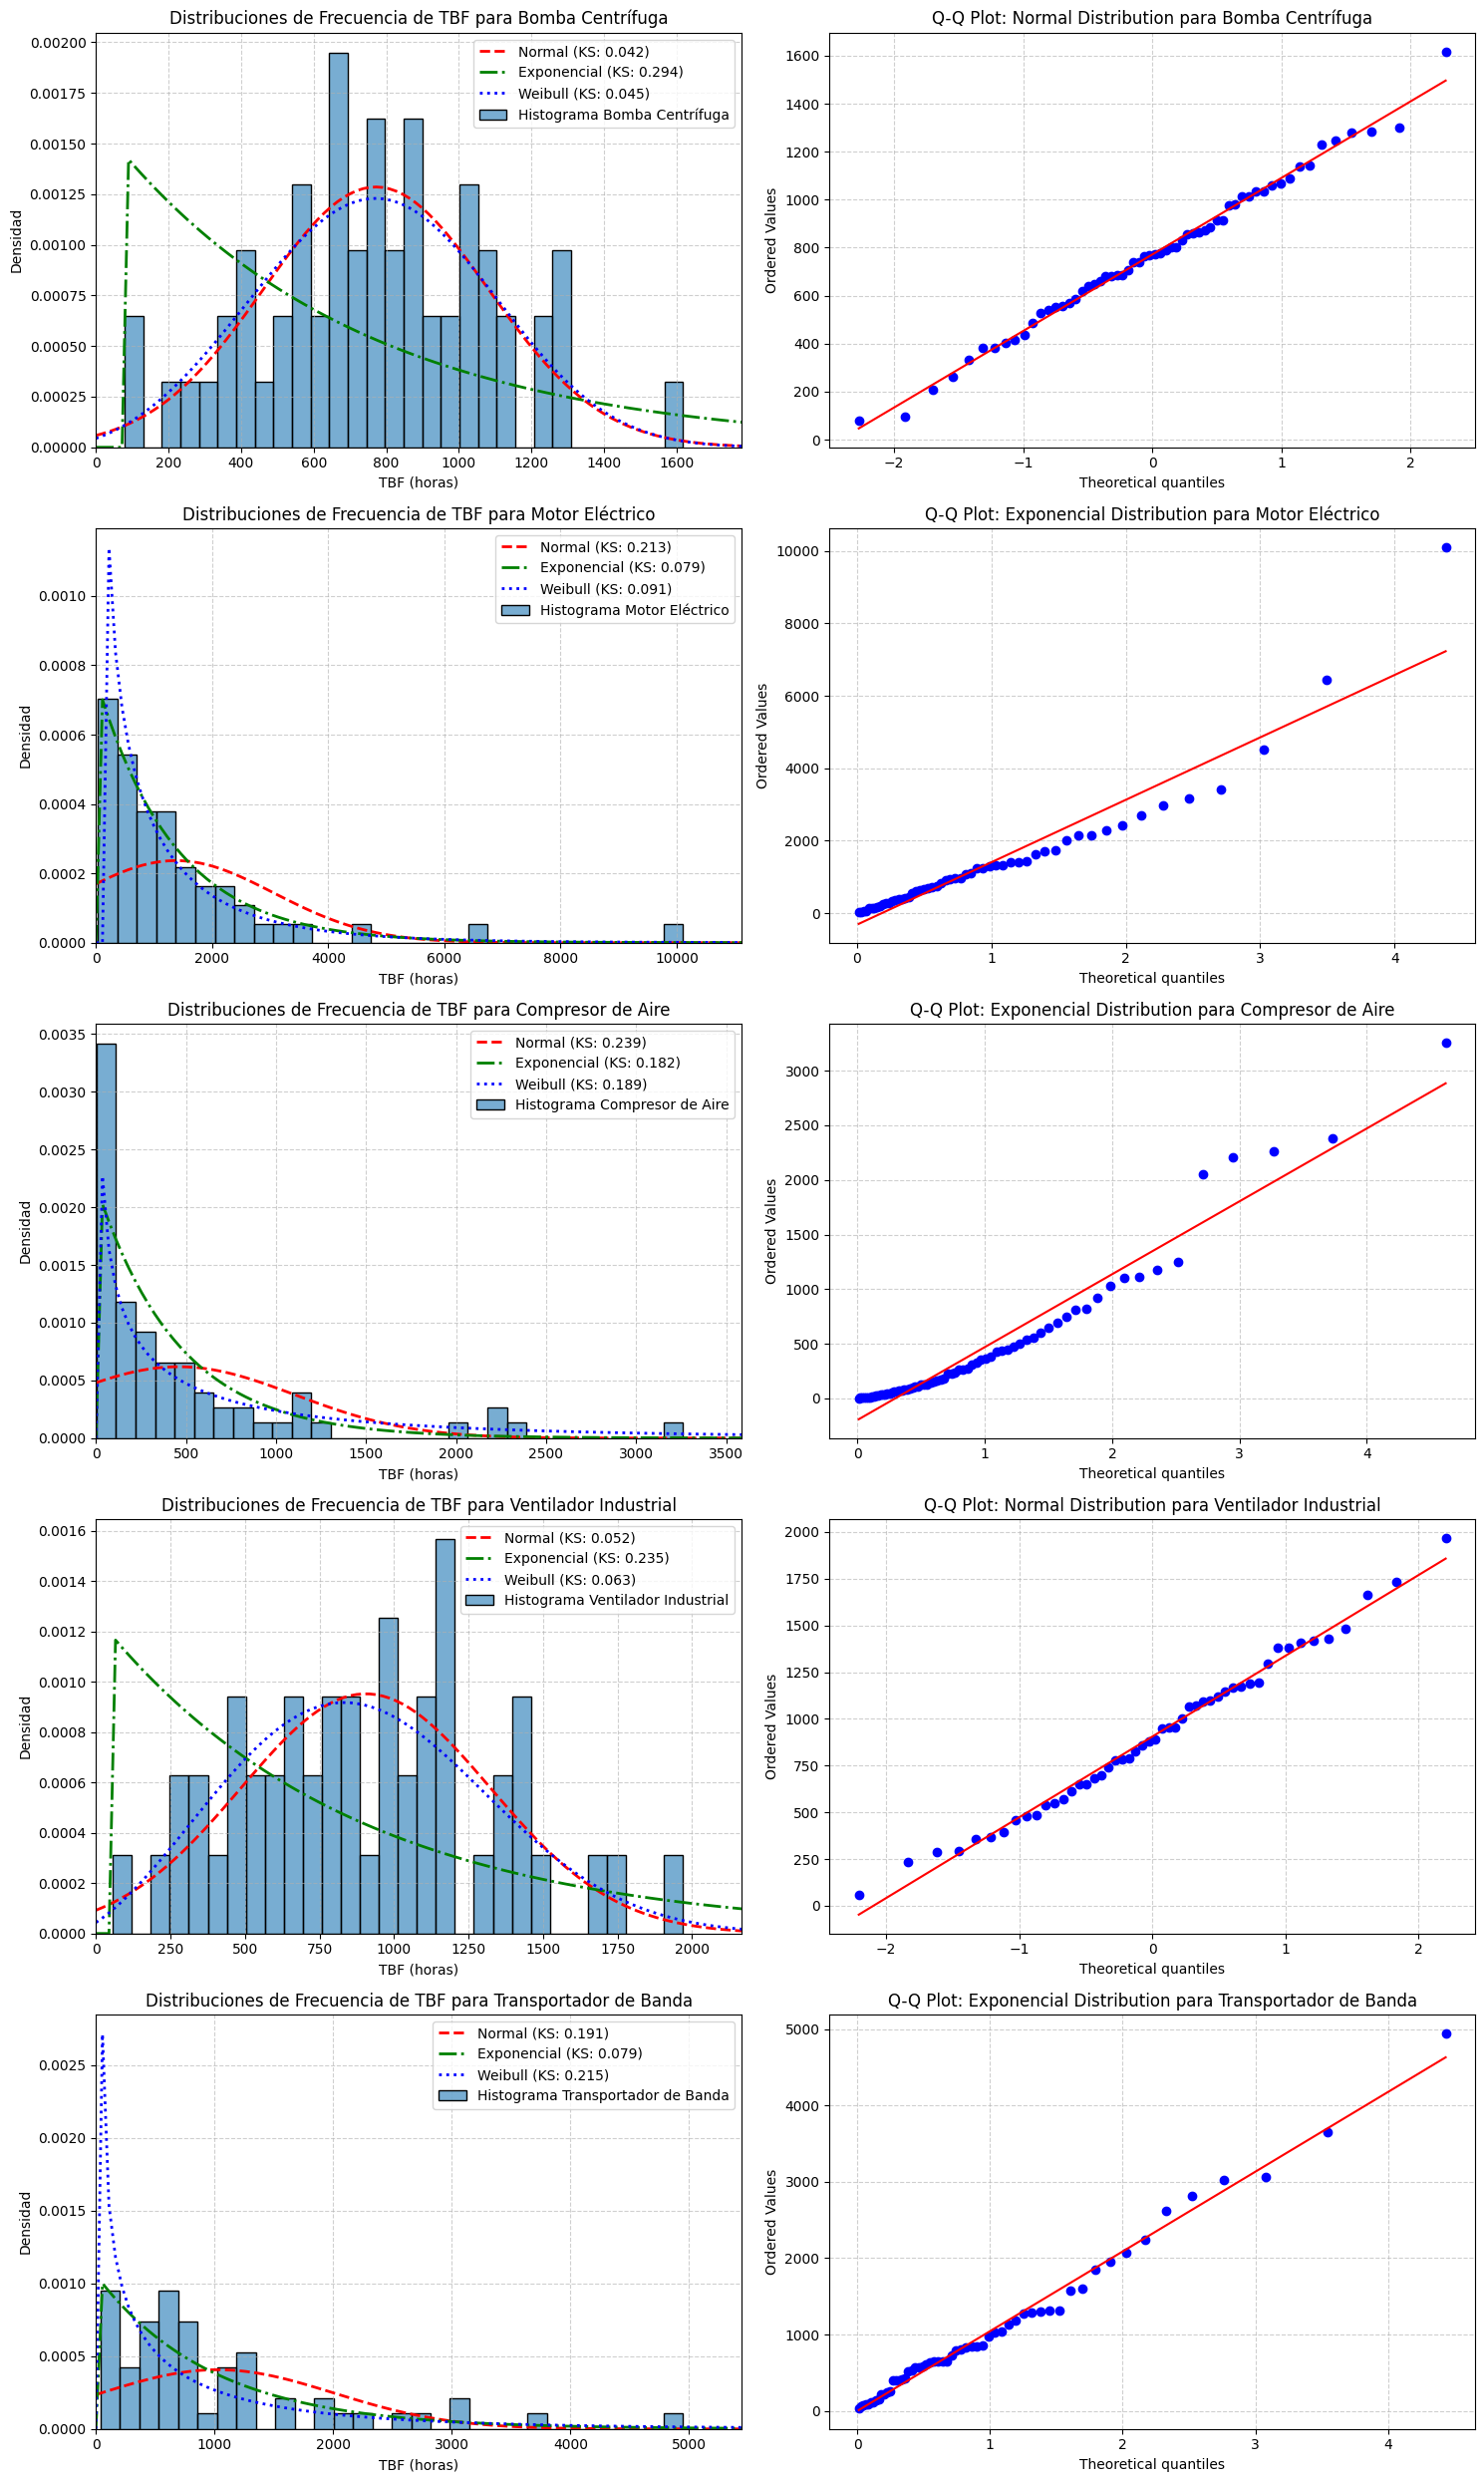

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import norm, expon, weibull_min, kstest, probplot # Ensure all imports are here

# Get the list of unique equipment names
equipment_names = fallas['equipo'].unique()

# Calculate the number of rows needed for subplots: 5 equipment * 2 plots each
n_rows = len(equipment_names)
n_cols = 2 # One column for histogram, one for Q-Q plot

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 5)) # Adjust figsize as needed

for i, current_equipment in enumerate(equipment_names):
    current_data = fallas[fallas['equipo'] == current_equipment]['tbf_horas']

    # Re-fit distributions for the current equipment to get parameters
    best_dist_name_current, dist_results_current = fit_and_test_distributions(current_data)

    # Get parameters for plotting
    mu_norm, std_norm = dist_results_current['Normal']['params']
    loc_expon, scale_expon = dist_results_current['Exponencial']['params']
    c_weibull, loc_weibull, scale_weibull = dist_results_current['Weibull']['params']

    # --- Plotting the histogram with superimposed densities ---
    ax_hist = axes[i, 0] # Get the current axis for the histogram

    sns.histplot(current_data, kde=False, bins=30, stat='density', alpha=0.6, label=f'Histograma {current_equipment}', ax=ax_hist)

    # Ensure xmin starts from 0 as TBF cannot be negative
    xmin_plot = 0
    xmax_plot = current_data.max() * 1.1 # Extend slightly beyond max for better visualization
    x = np.linspace(xmin_plot, xmax_plot, 100)

    # Plot Normal PDF
    p_norm = norm.pdf(x, mu_norm, std_norm)
    ax_hist.plot(x, p_norm, 'r--', linewidth=2, label=f'Normal (KS: {dist_results_current["Normal"]["KS_stat"]:.3f})')

    # Plot Exponential PDF
    p_expon = expon.pdf(x, loc_expon, scale_expon)
    ax_hist.plot(x, p_expon, 'g-.', linewidth=2, label=f'Exponencial (KS: {dist_results_current["Exponencial"]["KS_stat"]:.3f})')

    # Plot Weibull PDF
    p_weibull = weibull_min.pdf(x, c_weibull, loc_weibull, scale_weibull)
    ax_hist.plot(x, p_weibull, 'b:', linewidth=2, label=f'Weibull (KS: {dist_results_current["Weibull"]["KS_stat"]:.3f})')

    ax_hist.set_title(f'Distribuciones de Frecuencia de TBF para {current_equipment}')
    ax_hist.set_xlabel('TBF (horas)')
    ax_hist.set_ylabel('Densidad')
    ax_hist.legend()
    ax_hist.grid(True, linestyle='--', alpha=0.6)
    ax_hist.set_xlim(xmin_plot, xmax_plot) # Set x-axis limits explicitly

    # --- Q-Q plot for the best fitting distribution ---
    ax_qq = axes[i, 1] # Get the current axis for the Q-Q plot

    if best_dist_name_current == 'Normal':
        probplot(current_data, dist="norm", plot=ax_qq)
        ax_qq.set_title(f'Q-Q Plot: Normal Distribution para {current_equipment}')
    elif best_dist_name_current == 'Exponencial':
        probplot(current_data, dist="expon", plot=ax_qq)
        ax_qq.set_title(f'Q-Q Plot: Exponencial Distribution para {current_equipment}')
    elif best_dist_name_current == 'Weibull':
        c_weibull_qq, loc_weibull_qq, scale_weibull_qq = dist_results_current['Weibull']['params']
        probplot(current_data, dist=weibull_min, sparams=(c_weibull_qq, loc_weibull_qq, scale_weibull_qq), plot=ax_qq)
        ax_qq.set_title(f'Q-Q Plot: Weibull Distribution para {current_equipment}')
    else:
        ax_qq.set_title(f"No Q-Q plot disponible para {best_dist_name_current} en {current_equipment}")

    ax_qq.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Parte 3 — Clasificación del comportamiento

Con el parámetro de forma (β) de Weibull de cada equipo, clasifícalo como:

- **β < 1** → mortalidad infantil
- **β ≈ 1** → falla aleatoria
- **β > 1** → desgaste

Agrega una columna `comportamiento` a tu tabla resumen con esta clasificación.

In [ ]:
def classify_weibull_beta(beta):
    if beta < 1:
        return 'Mortalidad Infantil'
    elif beta >= 0.9 and beta <= 1.1: # Allowing a small range around 1 for 'random failure'
        return 'Falla Aleatoria'
    else:
        return 'Desgaste'

distribution_summary_df['comportamiento'] = distribution_summary_df['parámetro_forma_weibull'].apply(classify_weibull_beta)

display(distribution_summary_df)

,equipo,mejor_distribución,KS_stat,parámetro_forma_weibull,comportamiento
0,Bomba Centrífuga,Normal,0.042078,3.298940,Desgaste
1,Compresor de Aire,Exponencial,0.182081,0.657880,Mortalidad Infantil
2,Motor Eléctrico,Exponencial,0.079005,0.791832,Mortalidad Infantil
3,Transportador de Banda,Exponencial,0.079396,0.704059,Mortalidad Infantil
4,Ventilador Industrial,Normal,0.051973,2.551624,Desgaste


## Parte 4 — Visualización comparativa

Construye un solo gráfico de boxplots (uno por equipo, lado a lado u horizontal) que permita comparar visualmente la dispersión del TBF entre los 5 equipos — el mismo tipo de gráfico que vimos en el Notebook 1 (`sns.boxplot` + `sns.stripplot` superpuesto para ver los puntos individuales y los atípicos de cola larga).

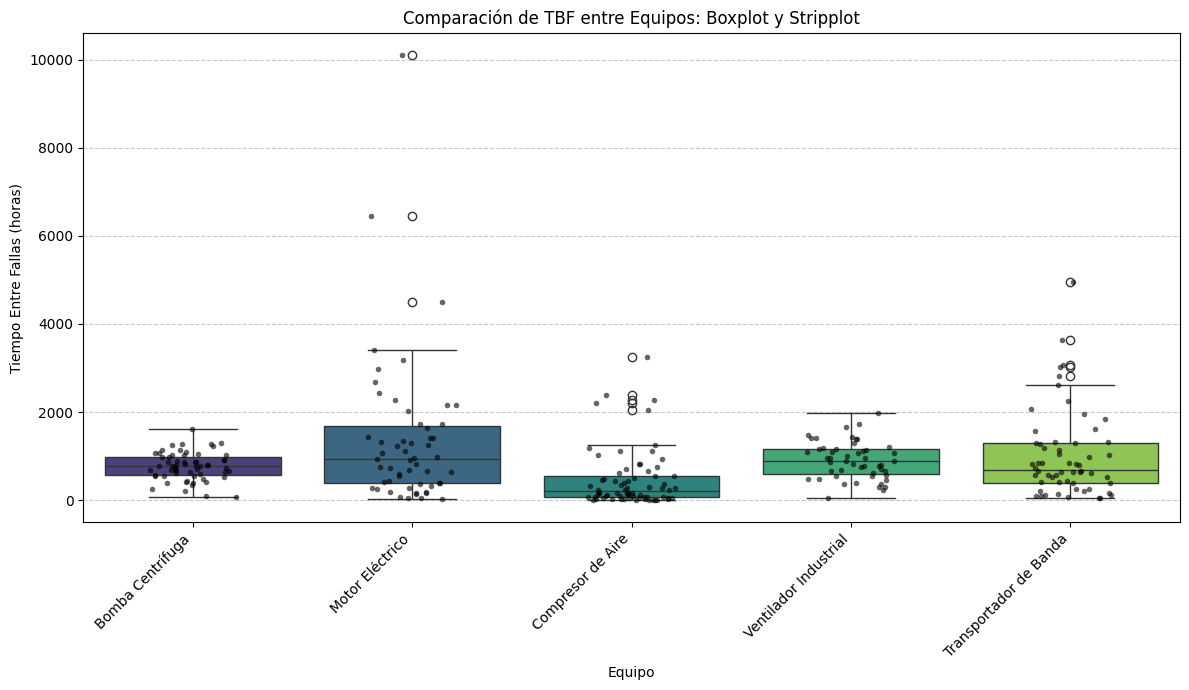

In [ ]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='equipo', y='tbf_horas', data=fallas, palette='viridis', hue='equipo', legend=False)
sns.stripplot(x='equipo', y='tbf_horas', data=fallas, color='black', size=4, jitter=0.2, alpha=0.6)

plt.title('Comparación de TBF entre Equipos: Boxplot y Stripplot')
plt.xlabel('Equipo')
plt.ylabel('Tiempo Entre Fallas (horas)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Parte 4.1 — Comparativas de Ajuste de Distribución y Comportamiento

### Comparación por el Estadístico KS (Mejor Ajuste)

A continuación, visualizamos el estadístico de Kolmogorov-Smirnov (KS) para la **mejor distribución ajustada** de cada equipo. Un valor de KS más bajo indica un mejor ajuste de la distribución a los datos. Esta gráfica nos permite ver visualmente qué equipos tienen datos que se ajustan mejor o peor a alguna de las distribuciones consideradas. Aunque el número de muestras influye en la significancia estadística del KS, aquí nos centramos en la magnitud del estadístico para comparar la bondad del ajuste relativo entre equipos.

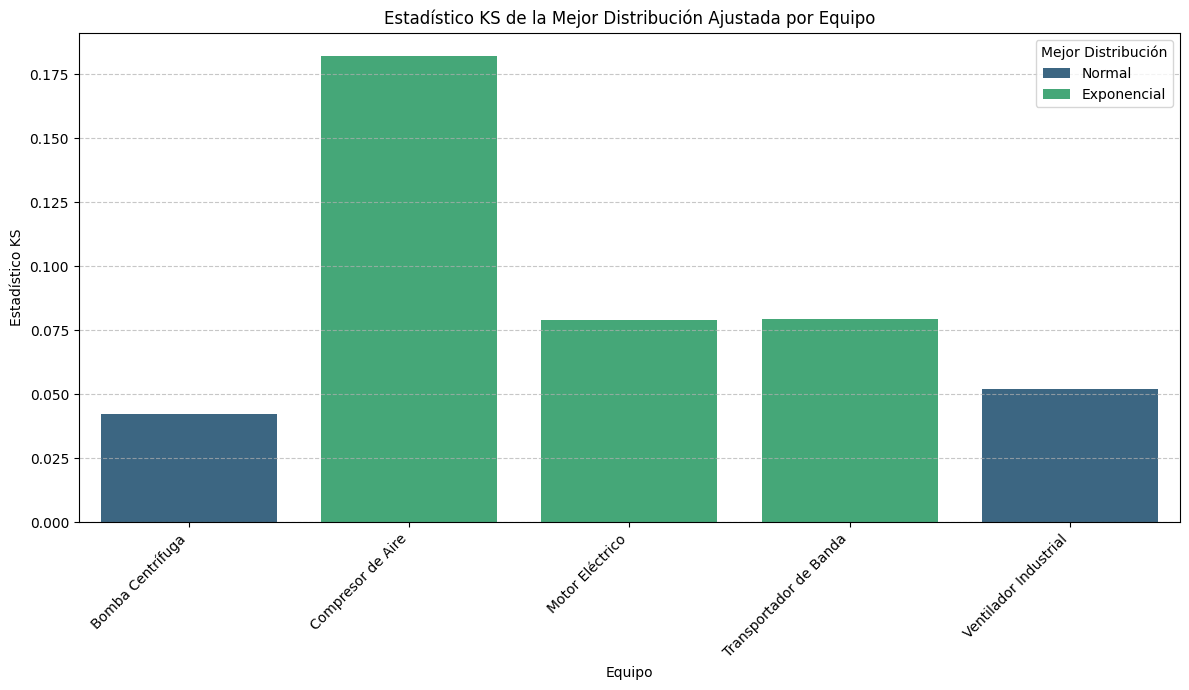

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='equipo', y='KS_stat', hue='mejor_distribución', data=distribution_summary_df, palette='viridis', dodge=False)
plt.title('Estadístico KS de la Mejor Distribución Ajustada por Equipo')
plt.xlabel('Equipo')
plt.ylabel('Estadístico KS')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Mejor Distribución')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Clasificación del Comportamiento de Falla por Parámetro de Forma Weibull (β)

El parámetro de forma (β) de la distribución de Weibull es crucial para entender el comportamiento de falla de un activo. Sus rangos típicos y su significado en la vida real son:

*   **β < 1 (Mortalidad Infantil):** Indica una tasa de falla decreciente. Esto es común en componentes recién instalados que fallan debido a defectos de fabricación, instalación incorrecta o pruebas iniciales. Una vez superado este período inicial, la tasa de falla se estabiliza o disminuye.
*   **β ≈ 1 (Falla Aleatoria):** Sugiere una tasa de falla constante (similar a una distribución exponencial). Las fallas ocurren de manera impredecible y no están relacionadas con la edad del componente. Esto puede deberse a choques externos, sobrecargas repentinas o fallas de componentes menores aleatorios.
*   **β > 1 (Desgaste):** Implica una tasa de falla creciente. A medida que el componente envejece, la probabilidad de falla aumenta. Este es el comportamiento esperado para la mayoría de los equipos que experimentan desgaste, fatiga o corrosión con el uso. Cuanto mayor sea β, más pronunciada será la curva de desgaste.

A continuación, se muestra una visualización de cómo se clasifica el comportamiento de falla para cada equipo según su parámetro β.

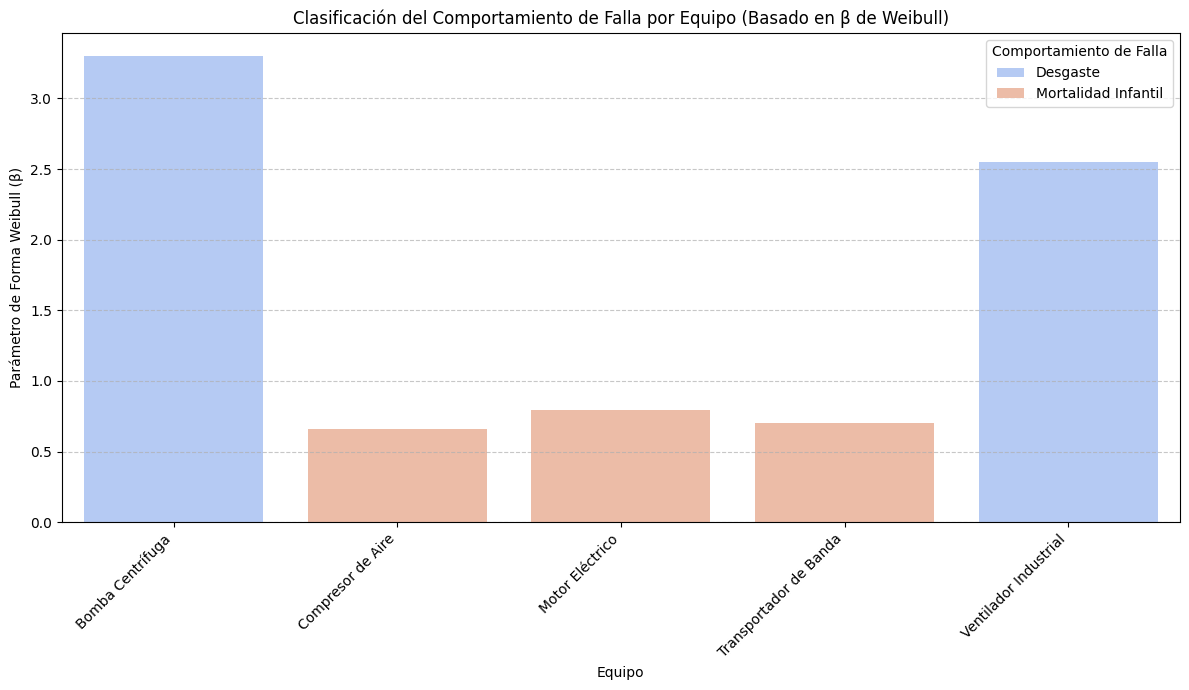

In [ ]:
# @title
def classify_weibull_beta(beta):
    if beta < 1:
        return 'Mortalidad Infantil'
    elif beta >= 0.9 and beta <= 1.1: # Allowing a small range around 1 for 'random failure'
        return 'Falla Aleatoria'
    else:
        return 'Desgaste'

# Ensure the 'comportamiento' column is always created/updated in this cell
distribution_summary_df['comportamiento'] = distribution_summary_df['parámetro_forma_weibull'].apply(classify_weibull_beta)

plt.figure(figsize=(12, 7))
sns.barplot(x='equipo', y='parámetro_forma_weibull', hue='comportamiento', data=distribution_summary_df, palette='coolwarm', dodge=False)
plt.title('Clasificación del Comportamiento de Falla por Equipo (Basado en β de Weibull)')
plt.xlabel('Equipo')
plt.ylabel('Parámetro de Forma Weibull (β)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Comportamiento de Falla')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Parte 5 — Conclusiones (obligatorio, mínimo 150 palabras)

Responde en esta celda: para cada equipo, ¿qué estrategia de mantenimiento recomendarías (preventivo por tiempo fijo, basado en condición, o revisión de puesta en marcha) y por qué? Sustenta tu respuesta con los números obtenidos, no solo con la clasificación de β.

Para los equipos que muestran mortalidad infantil de acuerdo a la teoría de RCM  y las normas aplicables ISO para estrategias de mantenimiento definen que la estrategia de mantenimiento mayormente aceptable para los casos bajo estudio se rigen principalmente por una inspección de puesta marcha para valores abruptos de betha como ocurre en motores eléctricos es recomendable implementar un mantenimiento basado en condición mediante herramientas predictivas como puede  análisis de termografía  y ultrasonido para la detección de fallas que no son tan perceptibles al sentido humano, mientras que los más estables como lo son compresores y transportadores la revisión de puesta en marcha debe ser complementada con mantenimiento preventivo considerando los gatos de reemplazo que ello conlleve para tocar temas como alineaciones o reemplazo de ejes monitoreando cargas de trabajo , para los equipos que se rigen por el desgaste es completamente recomendable un mantenimiento predictivo con la finalidad de optimizar la curva PF de los componentes